# Lab: Logistic Regression with scikit-learn
In the [theory notes](./08_logistic_regression_theory.md), we learned *what* Logistic Regression is: how the sigmoid function squashes a linear equation into a probability, and how the model uses gradient descent to find optimal parameters. In the [implementation file](./09_logistic_regression_implementation.py), we built it from scratch to solidify our understanding.

**Now it's time to see how the real world does it.** In this lab, we will learn how to:

1.  Load and prepare the Iris dataset for a **binary classification** task.
2.  Explore the data to understand why logistic regression is a good fit.
3.  Build a Logistic Regression model using **scikit-learn**.
4.  Interpret the model's coefficients and understand what they mean.
5.  Use the model to make predictions and predict probabilities.
6.  Visualize the decision boundary.

---

## 1. The Dataset and the Problem

We'll use the classic **Iris** dataset. It contains measurements for 150 iris flowers across 3 species: *setosa*, *versicolor*, and *virginica*. Since logistic regression is designed for **binary classification**, we'll frame our problem as:

> **Given the physical measurements of an iris flower, is it an *Iris-virginica* or not?**

Let's start by importing our libraries and loading the data.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.linear_model import LogisticRegression

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["figure.dpi"] = 150

In [2]:
# Load the Iris dataset from scikit-learn
raw_data = datasets.load_iris()

# Build a DataFrame from the raw data
iris_df = pd.DataFrame(raw_data.data, columns=["sepal_length", "sepal_width", "petal_length", "petal_width"])
iris_df["species"] = raw_data.target_names[raw_data.target]

iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


Good — 150 rows, no missing values, and all numerical features. Now let's create our binary target variable.

In [4]:
# Create binary target: 1 if virginica, 0 otherwise
iris_df["is_virginica"] = (iris_df["species"] == "virginica").astype(int)

print("Class distribution:")
print(iris_df["is_virginica"].value_counts())
print(f"\n0 = Not Virginica (setosa + versicolor): 100 samples")
print(f"1 = Virginica: 50 samples")

Class distribution:
is_virginica
0    100
1     50
Name: count, dtype: int64

0 = Not Virginica (setosa + versicolor): 100 samples
1 = Virginica: 50 samples


We have a **2:1 class imbalance** (100 "not virginica" vs. 50 "virginica"). This is worth noting — we'll keep it simple for this lab and proceed as-is.

---

## 2. Exploring the Data

Before fitting a model, let's see if the features can visually separate the two classes.

In [5]:
# Descriptive statistics
iris_df[["sepal_length", "sepal_width", "petal_length", "petal_width"]].describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


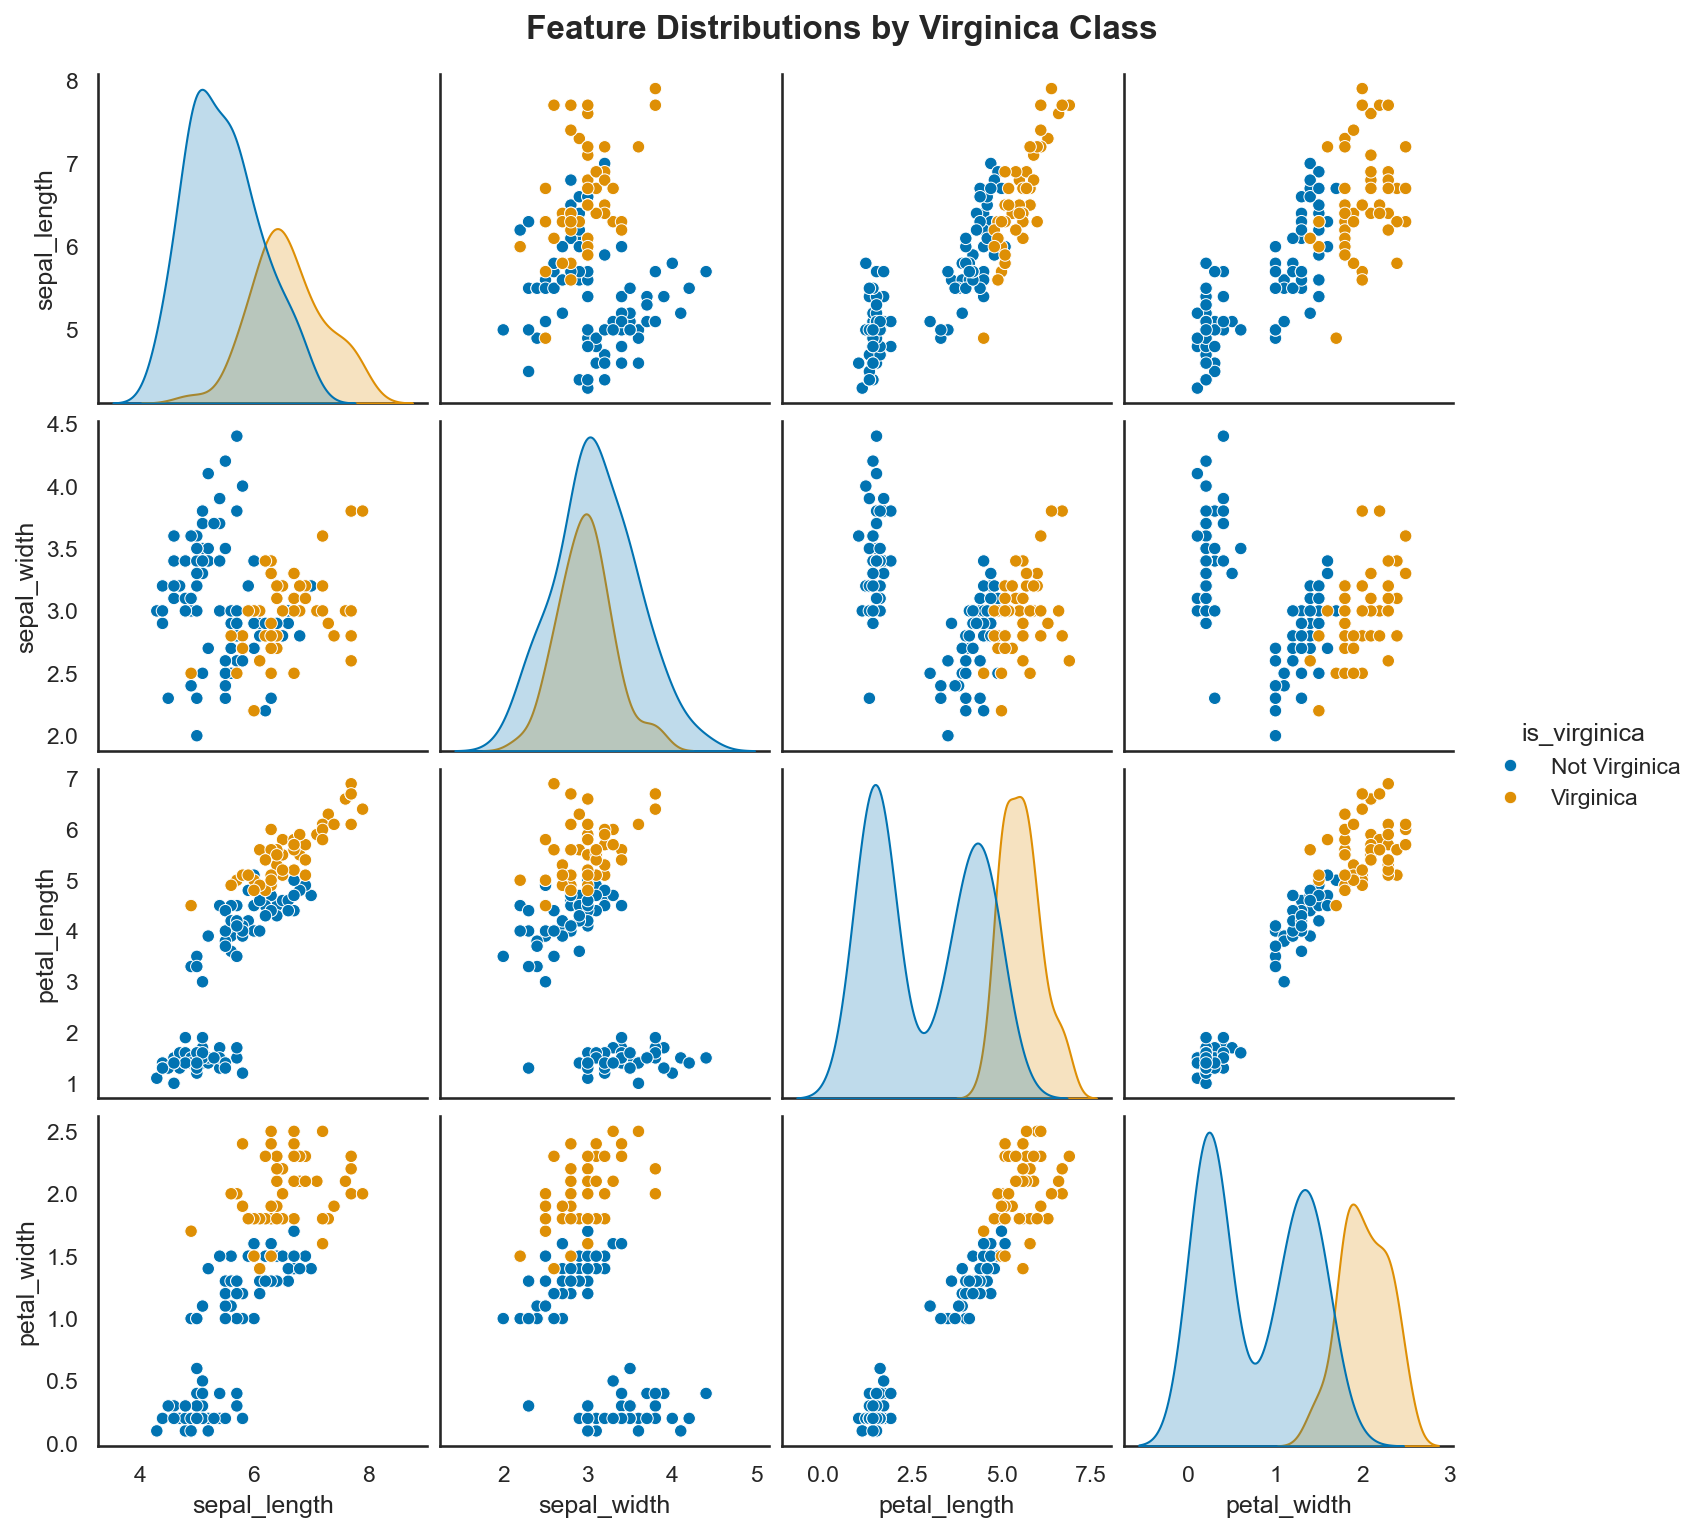

In [6]:
# Pair plot colored by our binary target
feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
plot_df = iris_df[feature_cols + ["is_virginica"]].copy()
plot_df["is_virginica"] = plot_df["is_virginica"].map({0: "Not Virginica", 1: "Virginica"})

pairplot = sns.pairplot(plot_df, hue="is_virginica")
pairplot.figure.suptitle("Feature Distributions by Virginica Class", fontsize=16, fontweight="bold", y=1.02)
plt.show()

The pair plot reveals several key insights:
* **Petal features** (`petal_length`, `petal_width`) show the clearest separation between Virginica and non-Virginica.
* **Sepal features** have more overlap between the two classes, making them weaker individual predictors.
* The classes are largely **linearly separable**, especially in the petal dimensions — this is great news for logistic regression.

Let's also check the correlations between features:

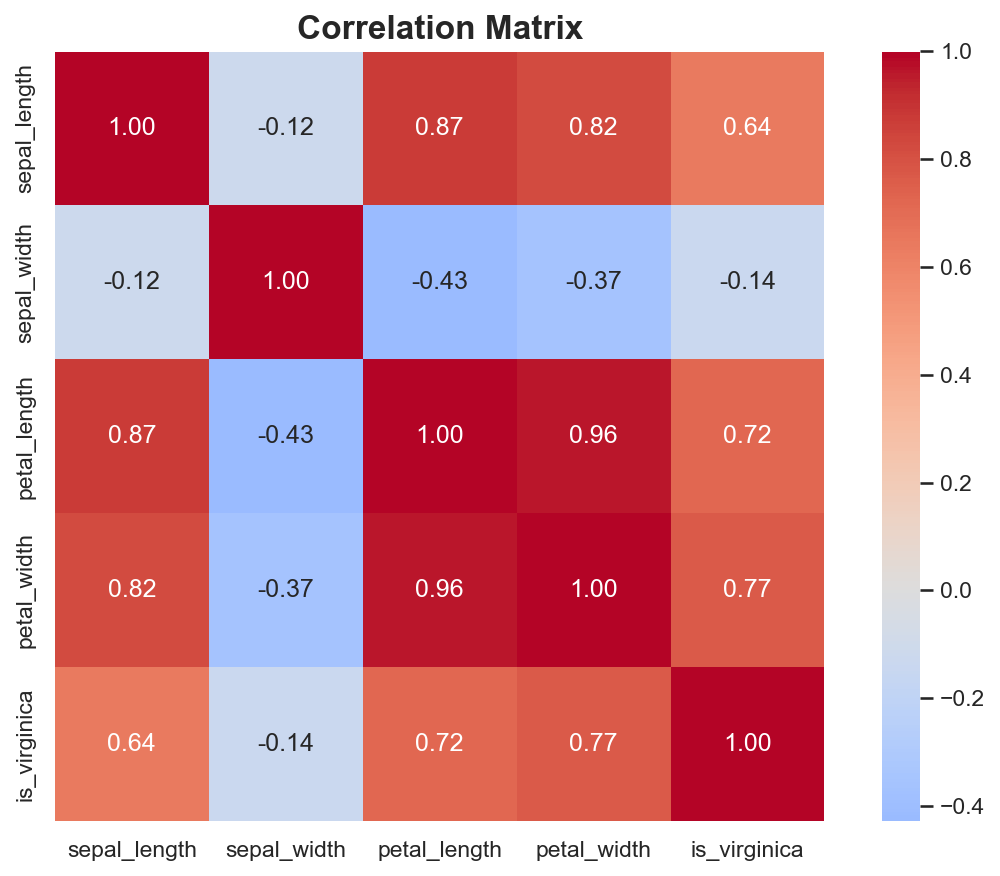

In [7]:
# Correlation heatmap
plt.figure()
corr_matrix = iris_df[feature_cols + ["is_virginica"]].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

As expected, `petal_length` and `petal_width` have the strongest positive correlation with `is_virginica`. Note also the high correlation *between* `petal_length` and `petal_width` — this is **multicollinearity**, something to be aware of with logistic regression (as discussed in the theory notes).

---

## 3. Building the Model with scikit-learn

This is the core of the lab. With scikit-learn, building a logistic regression model follows the same pattern as linear regression:

1.  **Prepare** `X` (features) and `y` (target).
2.  **Create** the model object.
3.  **Fit** the model to the data.
4.  **Inspect** the learned parameters.

### 3.1. Preparing X and y

In [8]:
# Feature matrix (all 4 measurements)
X = iris_df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]

# Binary target
y = iris_df["is_virginica"]

print(f"X shape: {X.shape}")  # Expected: (150, 4)
print(f"y shape: {y.shape}")  # Expected: (150,)
print(f"y unique values: {sorted(y.unique())}")

X shape: (150, 4)
y shape: (150,)
y unique values: [np.int64(0), np.int64(1)]


### 3.2. Creating and Fitting the Model

We create a `LogisticRegression` object and call `.fit()` to train it.

> **Note:** We set `max_iter=200` to ensure the optimization algorithm converges. The default (100) sometimes isn't enough for this dataset.

In [9]:
# Create and train the model
model = LogisticRegression(max_iter=200)
model.fit(X, y)

print("Model trained successfully!")

Model trained successfully!


### 3.3. Inspecting the Learned Parameters

Recall from the theory that logistic regression computes a linear combination of features, then passes it through the sigmoid function:

$$\hat{p} = \sigma(\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_3 + \theta_4 x_4)$$

scikit-learn stores these parameters as `.intercept_` ($\theta_0$) and `.coef_` ($\theta_1$ through $\theta_4$):

In [10]:
# Display the learned parameters
print(f"Intercept (θ₀): {model.intercept_[0]:.4f}")
print(f"\nCoefficients:")
for name, coef in zip(X.columns, model.coef_[0]):
    print(f"  {name}: {coef:.4f}")

Intercept (θ₀): -14.4360

Coefficients:
  sepal_length: -0.3927
  sepal_width: -0.5144
  petal_length: 2.9306
  petal_width: 2.4161


#### 📌 Interpreting the Coefficients

In logistic regression, the coefficients don't tell us "the change in y" directly (like in linear regression). Instead, they tell us how each feature affects the **log-odds** of the positive class.

**The sign matters most:**
- **Positive coefficient** → As this feature increases, the model becomes *more confident* the flower is a Virginica.
- **Negative coefficient** → As this feature increases, the model becomes *less confident* it's a Virginica.

Let's see which features push the prediction toward or away from "Virginica":

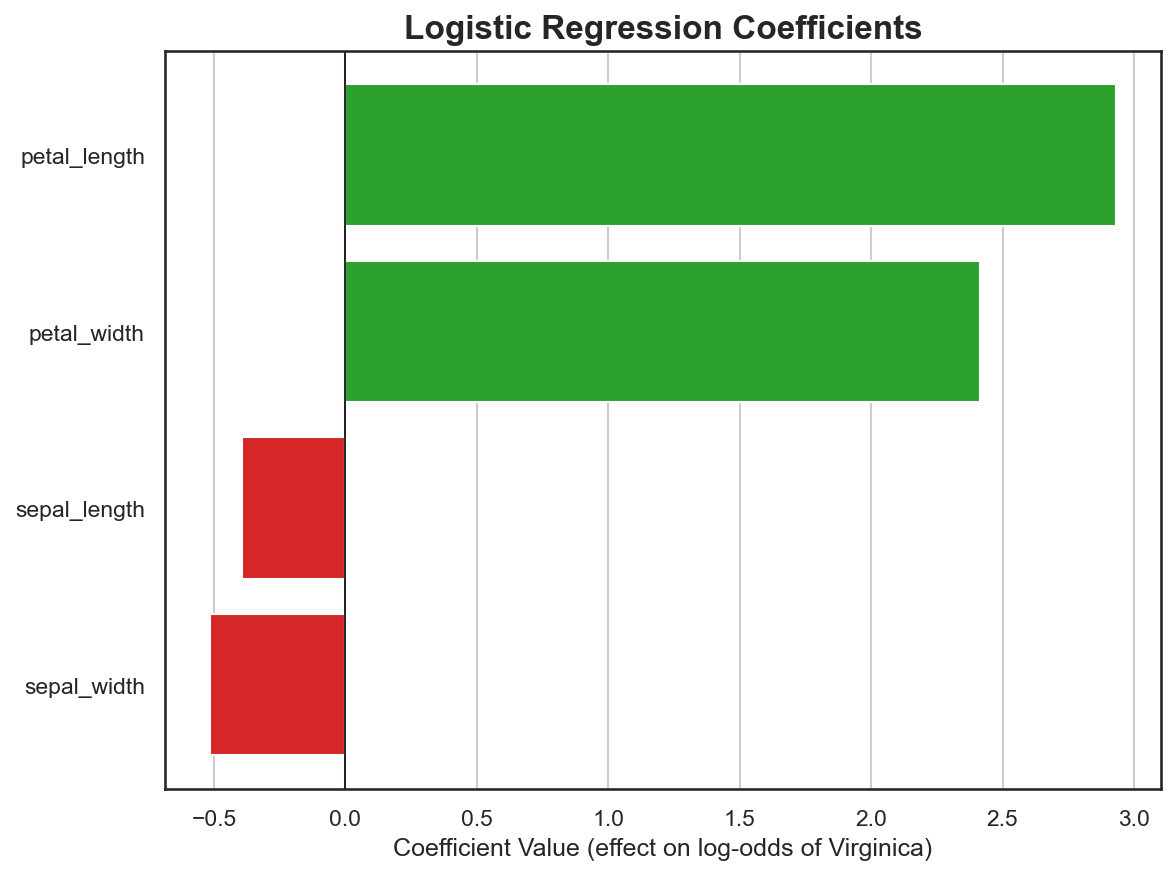

In [11]:
# Visualize the coefficients
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
}).sort_values("coefficient")

plt.figure()
colors = ["#d62728" if c < 0 else "#2ca02c" for c in coef_df["coefficient"]]
plt.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("Logistic Regression Coefficients", fontsize=16, fontweight="bold")
plt.xlabel("Coefficient Value (effect on log-odds of Virginica)")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

This aligns with what we saw in the pair plot — petal dimensions are the strongest discriminators.

---

## 4. Making Predictions

Logistic regression gives us **two types of output**:
- **`.predict(X)`**: The predicted class label (0 or 1), using the default 0.5 probability threshold.
- **`.predict_proba(X)`**: The predicted probability for each class.

Let's try both on some example flowers.

In [12]:
# Create some example flowers to classify
new_flowers = pd.DataFrame({
    "sepal_length": [5.0, 6.0, 7.0],
    "sepal_width":  [3.5, 2.7, 3.0],
    "petal_length": [1.4, 4.5, 6.0],
    "petal_width":  [0.2, 1.5, 2.3]
})

# Predict class labels
predicted_classes = model.predict(new_flowers)

# Predict probabilities
predicted_probs = model.predict_proba(new_flowers)

# Display results
result = new_flowers.copy()
result["predicted_class"] = predicted_classes
result["prob_not_virginica"] = np.round(predicted_probs[:, 0], 4)
result["prob_virginica"] = np.round(predicted_probs[:, 1], 4)
result["label"] = ["Not Virginica" if c == 0 else "Virginica" for c in predicted_classes]

print(result.to_string(index=False))

 sepal_length  sepal_width  petal_length  petal_width  predicted_class  prob_not_virginica  prob_virginica         label
          5.0          3.5           1.4          0.2                0              1.0000          0.0000 Not Virginica
          6.0          2.7           4.5          1.5                0              0.7972          0.2028 Not Virginica
          7.0          3.0           6.0          2.3                1              0.0120          0.9880     Virginica


Notice how:
- The first flower (small petals) gets a very low probability of being Virginica.
- The third flower (large petals) gets a very high probability.
- The middle flower is somewhere in between.

This is the sigmoid function at work — smoothly mapping the linear combination to a probability between 0 and 1.

---

## 5. Visualizing the Decision Boundary

To visualize how the model separates the two classes, we'll train a simplified model using **only the two best features** (`petal_length` and `petal_width`) and plot the decision boundary.

/Users/ibrahimkocyigit/Documents/repos/kocyigit-dsml/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


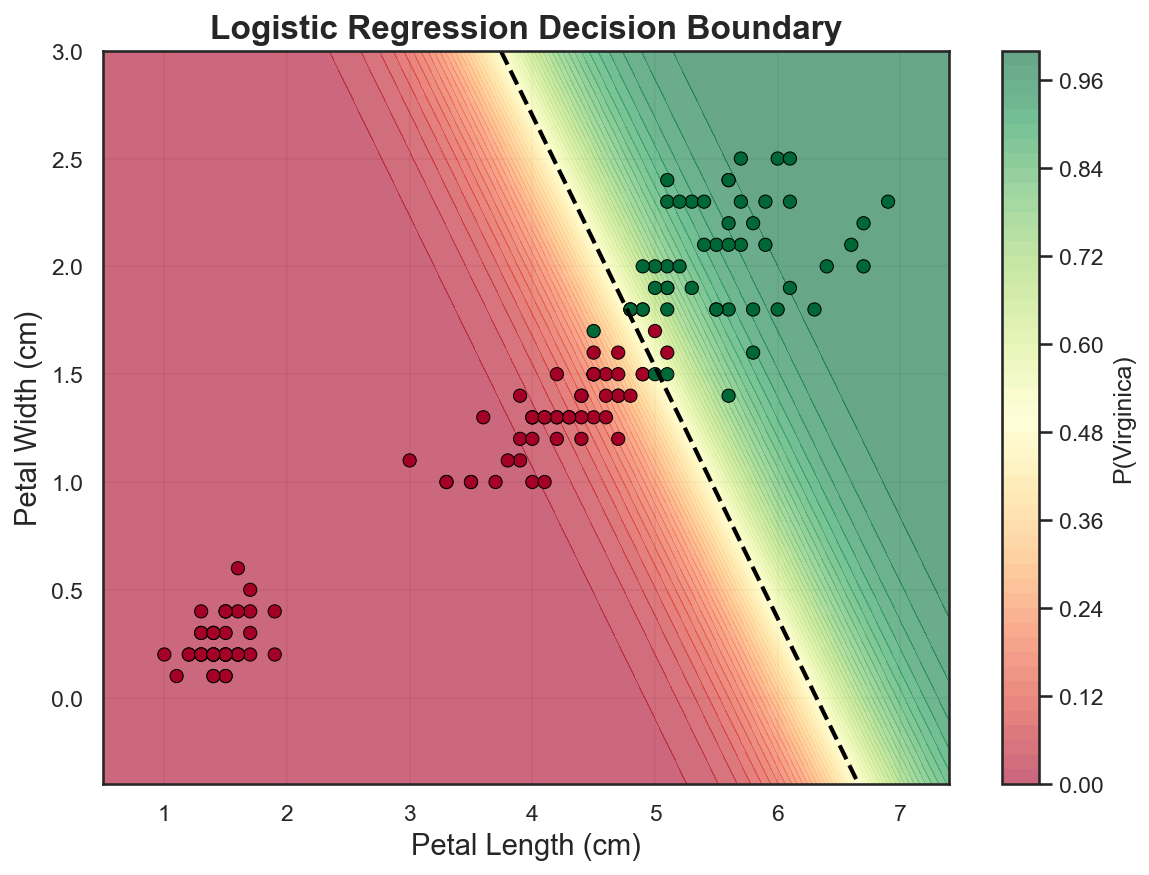

In [13]:
# Train a 2-feature model for visualization
X_2d = iris_df[["petal_length", "petal_width"]]
model_2d = LogisticRegression(max_iter=200)
model_2d.fit(X_2d, y)

# Create a mesh grid to plot the decision boundary
x_min, x_max = X_2d["petal_length"].min() - 0.5, X_2d["petal_length"].max() + 0.5
y_min, y_max = X_2d["petal_width"].min() - 0.5, X_2d["petal_width"].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

# Predict probabilities across the grid
Z = model_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# Plot
plt.figure()
plt.contourf(xx, yy, Z, levels=50, cmap="RdYlGn", alpha=0.6)
plt.colorbar(label="P(Virginica)")
plt.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2, linestyles="--")

# Plot actual data points
scatter = plt.scatter(
    X_2d["petal_length"], X_2d["petal_width"],
    c=y, cmap="RdYlGn", edgecolors="black", linewidths=0.5, s=40
)

plt.title("Logistic Regression Decision Boundary", fontsize=16, fontweight="bold")
plt.xlabel("Petal Length (cm)", fontsize=14)
plt.ylabel("Petal Width (cm)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The **dashed black line** is the decision boundary — the line where $P(\text{Virginica}) = 0.5$. The color gradient shows how the predicted probability changes smoothly across the feature space:

- **Red region** (bottom-left): Low probability → model predicts "Not Virginica"
- **Green region** (top-right): High probability → model predicts "Virginica"
- **Boundary**: The transition zone where the model is uncertain

This is exactly what we learned in theory — the sigmoid function creates a smooth probability gradient, and the decision boundary is where that probability crosses 0.5.

---

## Summary

In this lab, we learned how to use scikit-learn's `LogisticRegression` for binary classification. Here's what we covered:

| Step | What We Did | Key scikit-learn API |
|------|-------------|---------------------|
| Prepare data | Created features (`X`) and a binary target (`y`) | — |
| Create model | Instantiated a `LogisticRegression` object | `LogisticRegression()` |
| Train model | Fit the model to the data | `model.fit(X, y)` |
| Inspect parameters | Read the learned intercept and coefficients | `model.intercept_`, `model.coef_` |
| Predict classes | Predicted 0/1 labels for new data | `model.predict(X_new)` |
| Predict probabilities | Got the probability of each class | `model.predict_proba(X_new)` |

**Key takeaways:**
- Logistic regression outputs **probabilities**, not just class labels.
- The coefficients tell us the **direction and strength** of each feature's influence on the log-odds.
- The decision boundary is a **linear separator** in the feature space, with the sigmoid function creating the smooth probability transition.
- Petal measurements are far more discriminative than sepal measurements for distinguishing Virginica from other species.

---

**Next:** [Non-linear Regression Theory](../03_non-linear_and_ensemble_models/01_non-linear_regression_theory.md)